# Analisi delle immagini, riscritto in grazia

## Importazione delle librerie



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from math import sqrt
import time
import re
from scipy import signal
import ipywidgets as widgets
from src.analisi.tools import *

In [2]:
%matplotlib widget
plt.close('all')

In [3]:
# selettore cartella
folder_selector = widgets.Dropdown(
    options=sorted([f for f in os.listdir(base_img_folder) if os.path.isdir(os.path.join(base_img_folder, f))], reverse=True),
    description='Sessione:',
    style={'description_width': 'initial'}
)

display(folder_selector)

Dropdown(description='Sessione:', options=('2026-04-29_18-37-09', '2026-04-29_18-06-55'), style=DescriptionSty…

In [4]:
# caricamento dati
data_folder = os.path.join(base_img_folder, folder_selector.value)
image_folder = os.path.join(data_folder, "images")
bilancia_file = os.path.join(data_folder, "data", "points.txt")

try: 
    images, image_timestamps = load_images_from_folder(image_folder)
    images, image_timestamps = sort_images_and_timestamps(images, image_timestamps)

    bilancia_timestamps, bilancia_rates, bilancia_thicknesses = load_bilancia_data(bilancia_file)

    # converti i timetsmp in secondi
    image_seconds = [time.mktime(time.strptime(ts, FORMATO_COMUNE)) for ts in image_timestamps]
    bilancia_seconds = [time.mktime(time.strptime(ts, FORMATO_COMUNE)) for ts in bilancia_timestamps]

    # timestamp più alto comune tra immagini e bilancia
    max_t = min(image_seconds[-1], bilancia_seconds[-1])

    # timestamp nello stesso intervallo
    image_seconds = [t for t in image_seconds if t <= max_t]
    bilancia_seconds = [t for t in bilancia_seconds if t <= max_t]

    # dati nello stesso intervallo
    images = images[:len(image_seconds)]
    image_timestamps = image_timestamps[:len(image_seconds)]
    bilancia_rates = bilancia_rates[:len(bilancia_seconds)]
    bilancia_thicknesses = bilancia_thicknesses[:len(bilancia_seconds)]

except Exception as e:
    print(f"Errore caricamento dati: {e}")
    images, image_timestamps = [], []
    bilancia_timestamps, bilancia_rates, bilancia_thicknesses = [], [], []

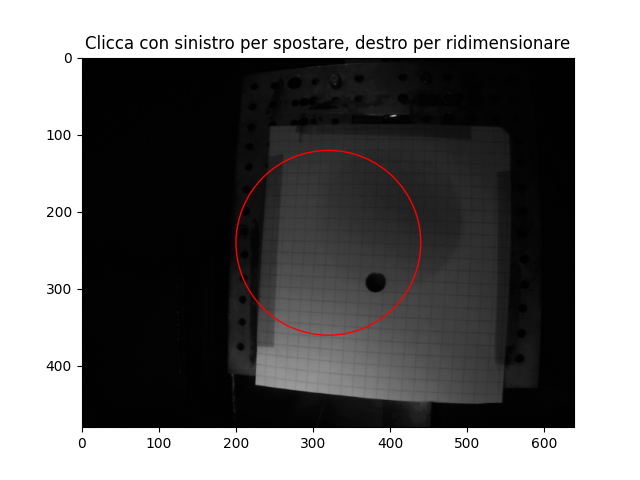

In [5]:
# preparazione reference image e selezione ROI
reference_image = np.mean(images[:10], axis=0).astype(np.uint8) if images else None
roi_selector = RoiSelectorWidget(reference_image)

In [29]:
# elaborazione immagini (calcolo differenze, estrazione ROI, profili, ecc.)

roi_center, roi_radius = roi_selector.roi
roi_images = extract_roi_from_images(images, roi_center, roi_radius)
reference_image_roi = extract_roi_from_images([reference_image], roi_center, roi_radius)[0]
difference_images = compute_difference_from_reference(roi_images, reference_image_roi)

In [30]:
window_size_slider = widgets.IntSlider(value=5, min=1, max=50, step=1, description='Window Size:', style={'description_width': 'initial'})
display(window_size_slider)

IntSlider(value=5, description='Window Size:', max=50, min=1, style=SliderStyle(description_width='initial'))

In [41]:
cut_start_slider = widgets.IntSlider(value=0, min=0, max=len(difference_images)-1, step=1, description='Cut Start:', style={'description_width': 'initial'})
display(cut_start_slider)

IntSlider(value=0, description='Cut Start:', max=177, style=SliderStyle(description_width='initial'))

In [46]:
# taglia l'inizio dai dati secondo lo slider
cut_start = cut_start_slider.value

difference_images = difference_images[cut_start:]
image_seconds = image_seconds[cut_start:]

bilancia_rates = bilancia_rates[cut_start:]
bilancia_thicknesses = bilancia_thicknesses[cut_start:]
bilancia_seconds = bilancia_seconds[cut_start:]

In [47]:
average_differences = moving_average_images(difference_images, window_size_slider.value)

In [48]:
average_intensities = compute_average_intensity(average_differences)

line_profiles = extract_line_profiles_circle_np(average_differences, roi_center, roi_radius, num_profiles=10, num_samples=roi_radius * 2)
avg_line_profiles = np.mean(line_profiles, axis=1)


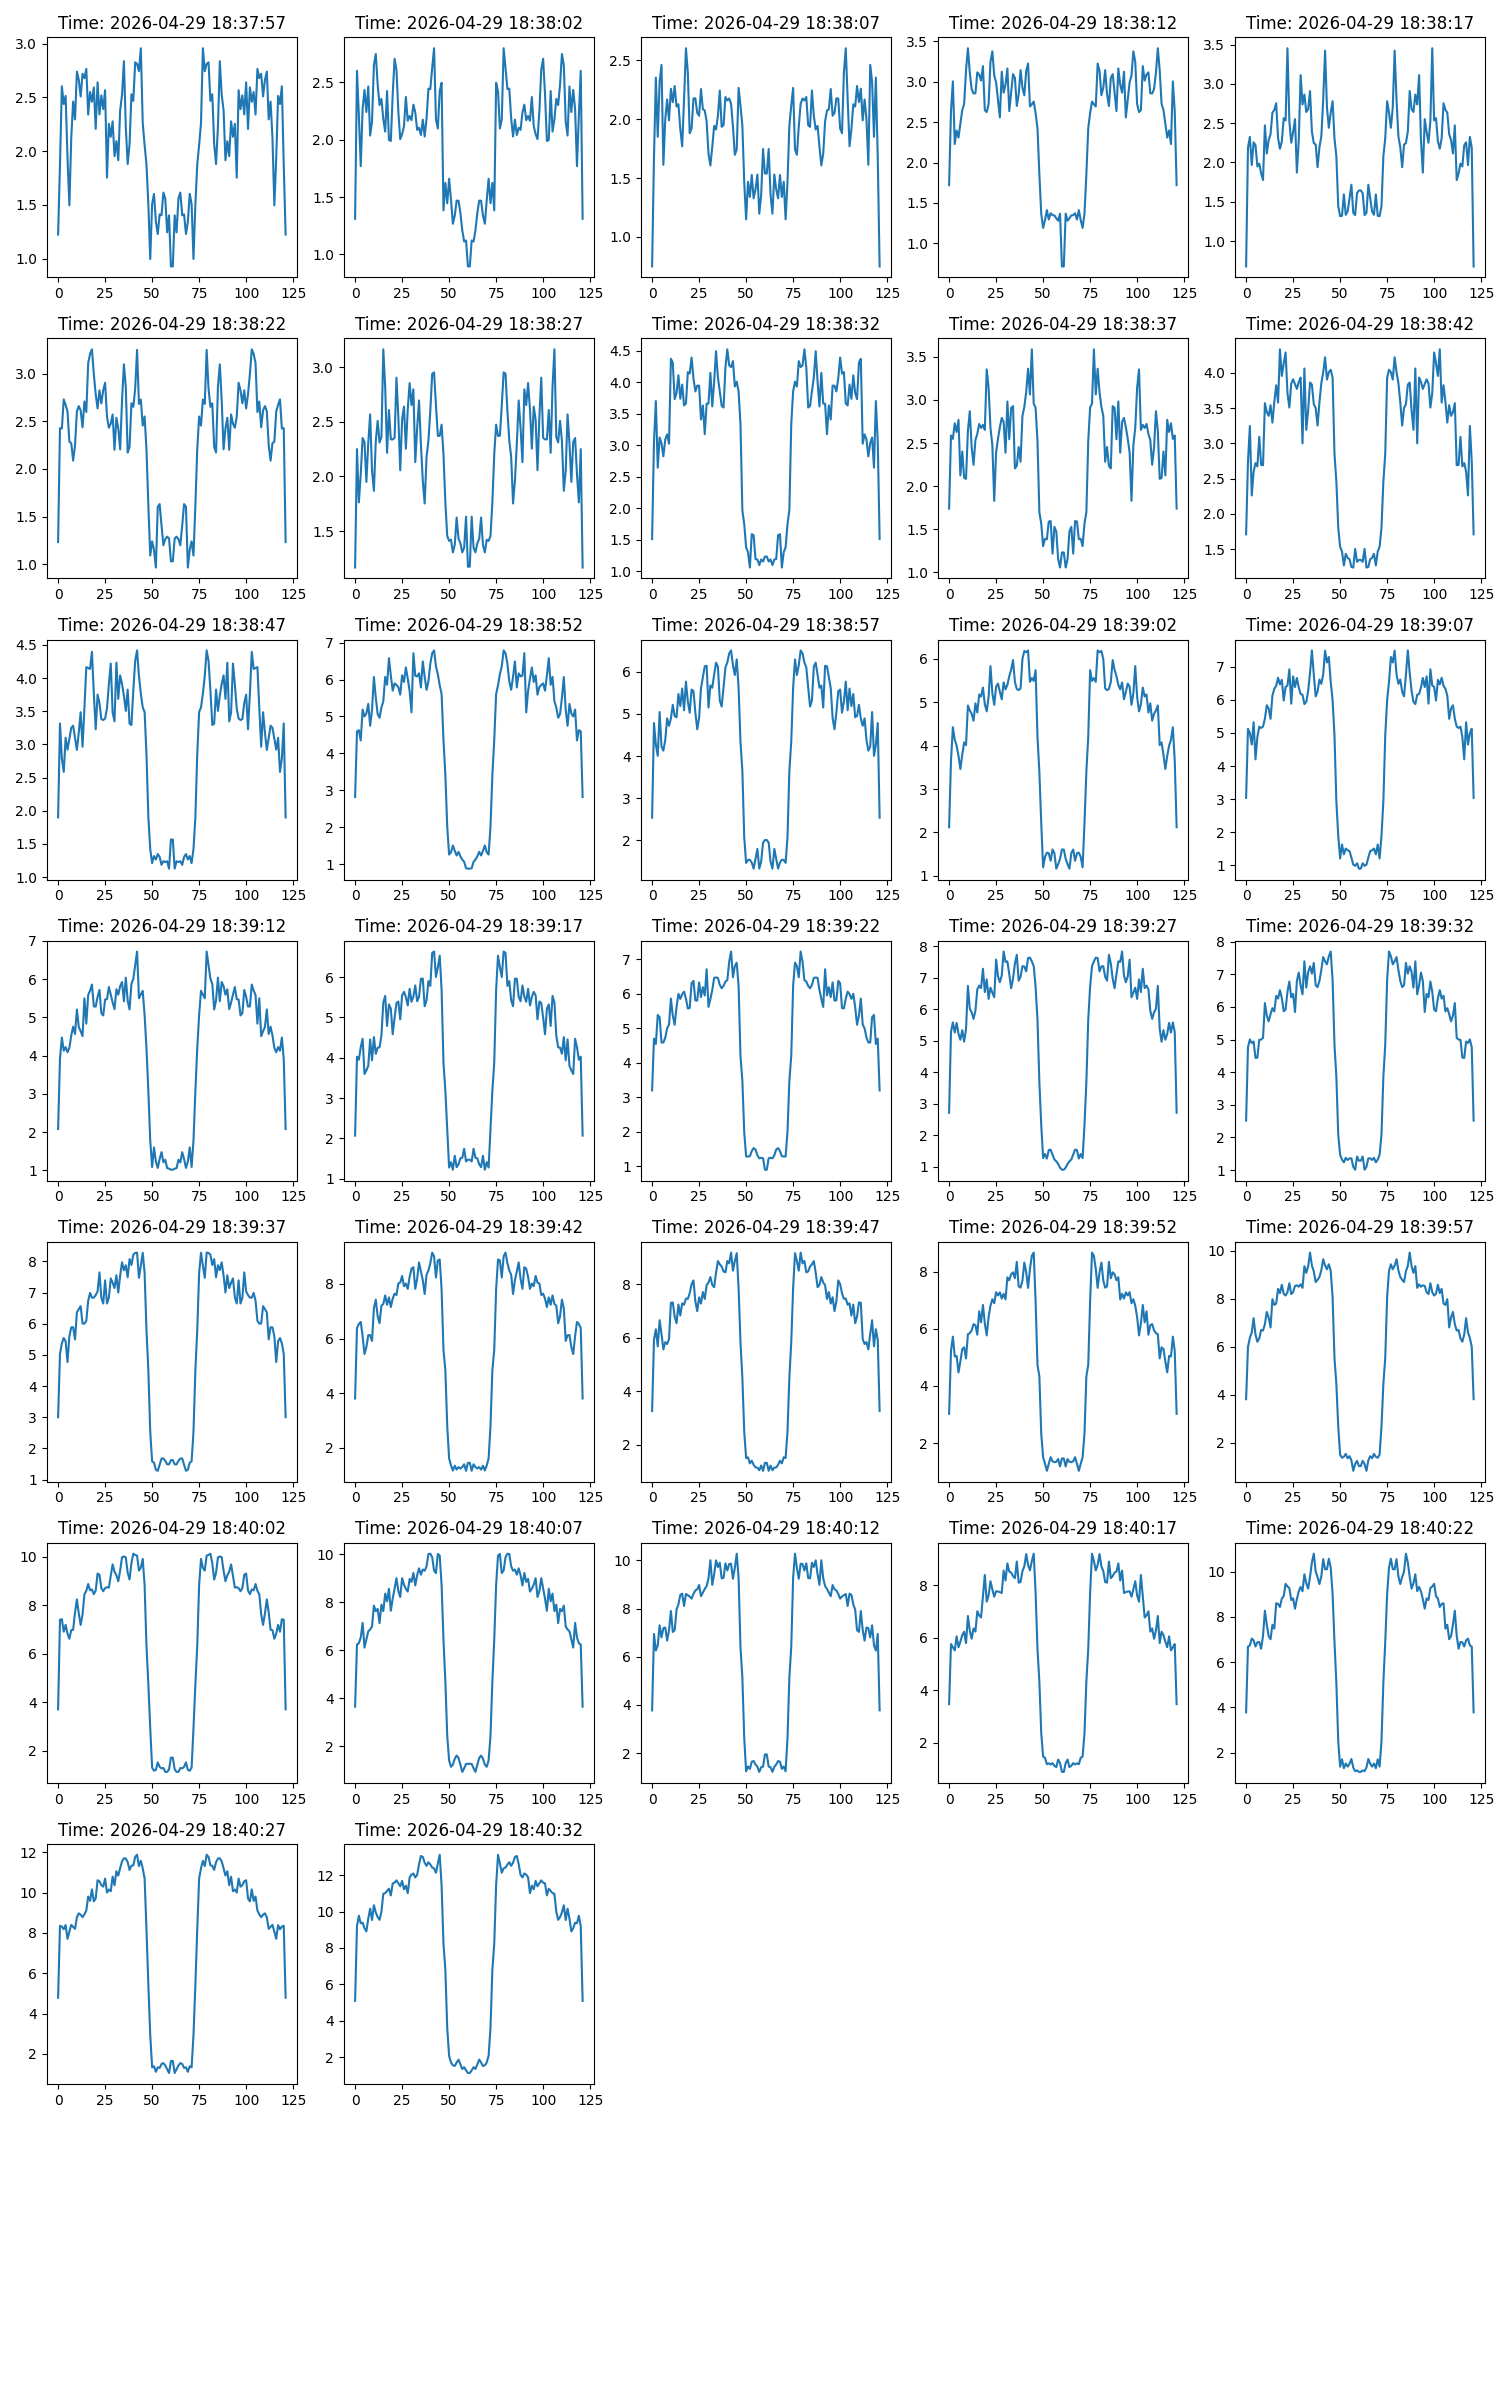

In [49]:
# disegna line profiles
step = 5

ncols = 5
nrows = (len(avg_line_profiles) // step + ncols - 1) // ncols + 1

plt.figure(figsize=(15, 3*nrows))


plt.subplot(nrows, ncols, 1)
for i in range(0, len(avg_line_profiles), step):
    plt.subplot(nrows, ncols, i // step + 1)
    plt.plot(avg_line_profiles[i])
    plt.title(f'Time: {image_timestamps[i]}')

plt.tight_layout()
plt.show()

In [50]:
# interpola dati bilancia per avere valori corrispondenti ai timestamp delle immagini
bilancia_rates_interp = np.interp(image_seconds, bilancia_seconds, bilancia_rates)
bilancia_thicknesses_interp = np.interp(image_seconds, bilancia_seconds, bilancia_thicknesses)

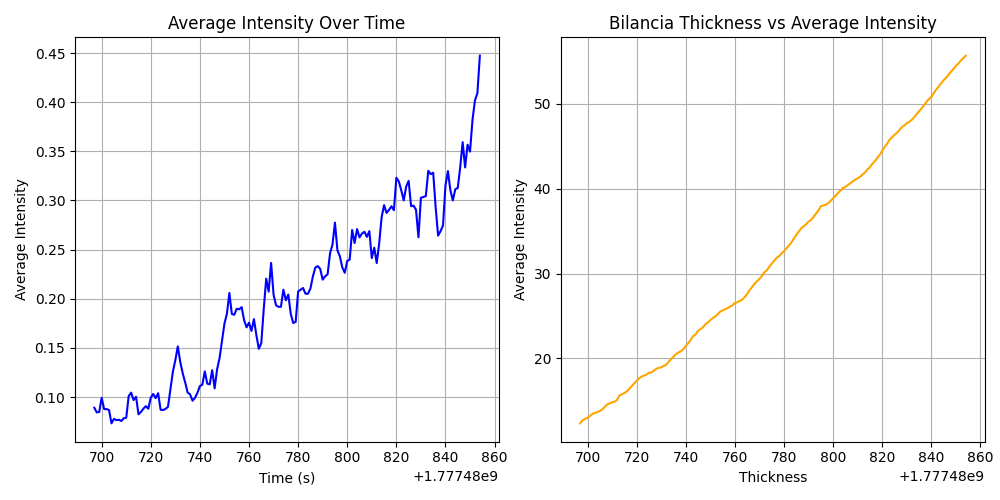

In [51]:
# plot bilancia vs intensità media
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(image_seconds, average_intensities, label='Average Intensity', color='blue')
plt.xlabel('Time (s)')
plt.ylabel('Average Intensity')
plt.title('Average Intensity Over Time')
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(image_seconds, bilancia_rates_interp, label='Bilancia Thickness', color='orange')
plt.xlabel('Thickness')
plt.ylabel('Average Intensity')
plt.title('Bilancia Thickness vs Average Intensity')
plt.grid()
plt.tight_layout()
plt.show()

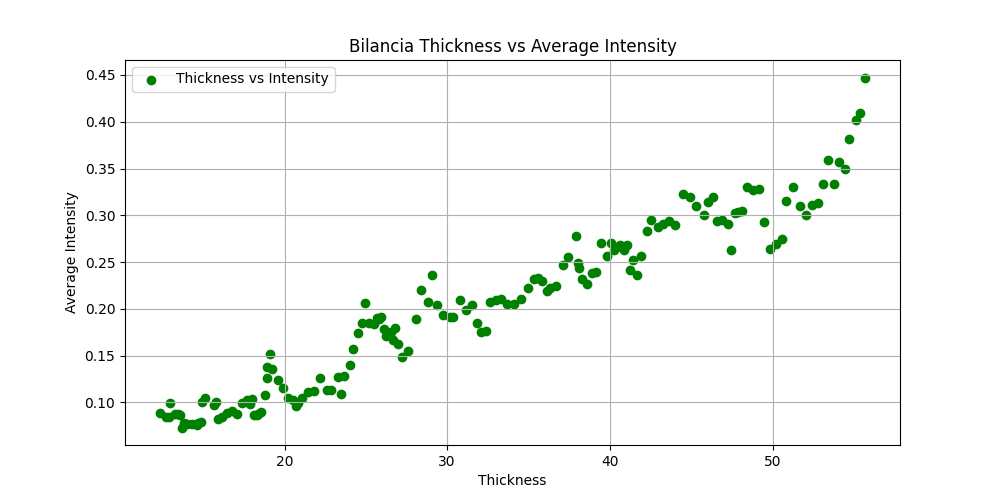

In [52]:
# scatter plot di bilancia vs intensità media
plt.figure(figsize=(10, 5))

plt.scatter(bilancia_rates_interp, average_intensities, label='Thickness vs Intensity', color='green')
plt.xlabel('Thickness')
plt.ylabel('Average Intensity')
plt.title('Bilancia Thickness vs Average Intensity')
plt.legend()
plt.grid()
plt.show()

Coefficients: [139.8692769    3.66572082]
Standard Deviation: 3.1044975263468895


/tmp/ipykernel_14411/2908524004.py:14: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 5))


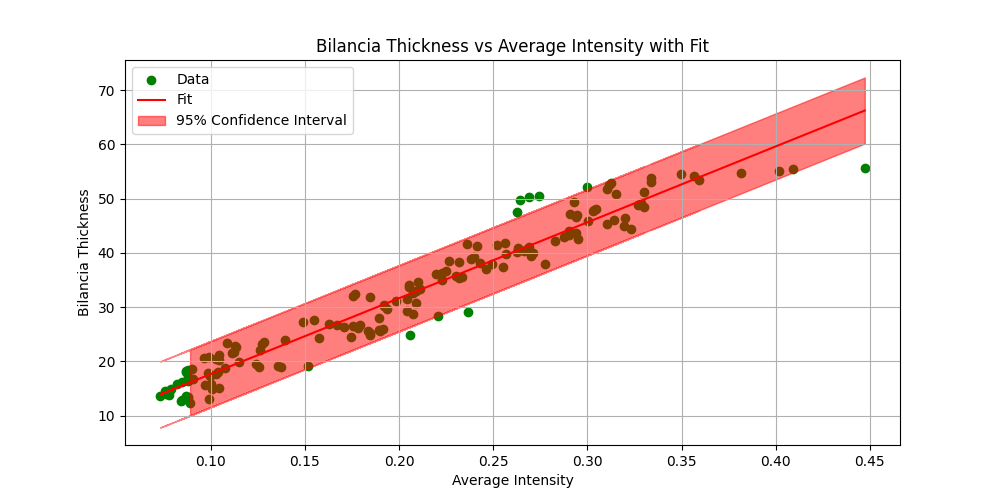

In [53]:
# fitta una retta ai dati
coefficients, residuals, rank, s, rcon = np.polyfit(average_intensities, bilancia_rates_interp, 1, full=True)
polynomial = np.poly1d(coefficients)
fitted_intensities = polynomial(average_intensities)

std_dev = np.sqrt(residuals[0] / (len(average_intensities) - 2))

confidence_max = polynomial(average_intensities) + 1.96 * std_dev
confidence_min = polynomial(average_intensities) - 1.96 * std_dev

print(f"Coefficients: {coefficients}")
print(f"Standard Deviation: {std_dev}")

plt.figure(figsize=(10, 5))
plt.scatter(average_intensities, bilancia_rates_interp, label='Data', color='green')
plt.plot(average_intensities, fitted_intensities, label='Fit', color='red')
plt.fill_between(average_intensities, confidence_min, confidence_max, color='red', alpha=0.5, label='95% Confidence Interval')
plt.xlabel('Average Intensity')
plt.ylabel('Bilancia Thickness')
plt.title('Bilancia Thickness vs Average Intensity with Fit')
plt.legend()
plt.grid()
plt.show()

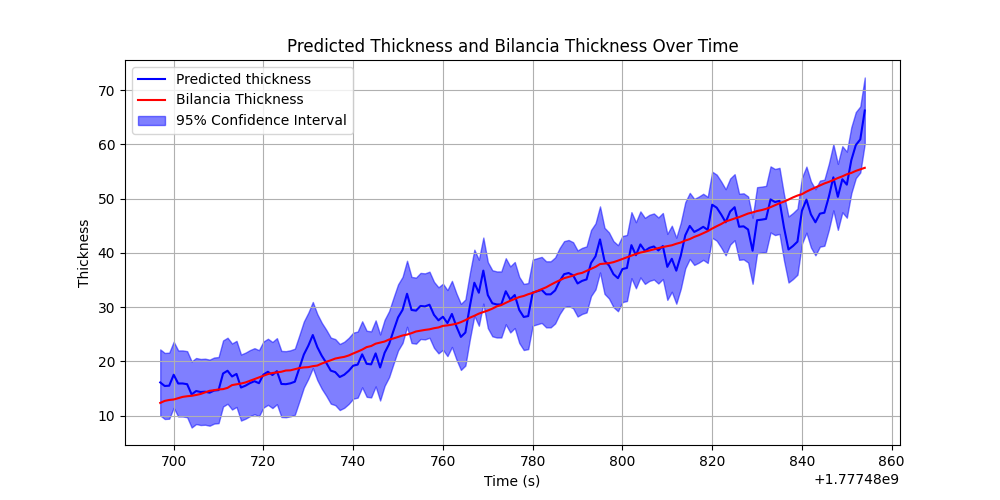

In [54]:
# plotta proiezione vs bilancia con confidence interval
plt.figure(figsize=(10, 5))

plt.plot(image_seconds, fitted_intensities, label='Predicted thickness', color='blue')
plt.plot(image_seconds, bilancia_rates_interp, label='Bilancia Thickness', color='red')

plt.fill_between(image_seconds, confidence_min, confidence_max, color='blue', alpha=0.5, label='95% Confidence Interval')

plt.xlabel('Time (s)')
plt.ylabel('Thickness')
plt.title('Predicted Thickness and Bilancia Thickness Over Time')
plt.legend()
plt.grid()
plt.show()